In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


#Dataset Loading And Preparation

##Dataset

The exploratory analysis utilises the **Online Retail Dataset** from the UCI Machine Learning Repository. The data consists of invoice data from a UK-based retailer between December 2010 and December 2011.

Source: UCI Machine Learning Repository
Link: https://archive.ics.uci.edu/dataset/352/online+retail

The project focuses on developing a statistical forecasting baseline for a future machine learning model using the data previously used for the exploratory analysis (https://github.com/NewLifeStyle101/OnlineRetailEDA) where we have concluded that the differenced data has achieved stationarity. Through the application of the ARIMA model evaluated using the mean absolute error loss function.

In [ ]:
dataset = pd.read_excel("./Online Retail.xlsx")

In [ ]:
dataset.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


###Data Preprocessing

In [ ]:
print(f"Negative Price: {dataset[dataset['UnitPrice'] < 0].shape}")

Negative Price: (2, 8)


In [ ]:
print(dataset[dataset['UnitPrice'] < 0])

       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        UnitPrice  CustomerID         Country  
299983  -11062.06         NaN  United Kingdom  
299984  -11062.06         NaN  United Kingdom  


In [ ]:
print(f"Negative Quantity: {dataset[dataset['Quantity'] < 0].shape}")

Negative Quantity: (10624, 8)


In [ ]:
print(dataset[dataset['Quantity'] < 0])

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

               InvoiceDate  UnitPrice  CustomerID         Country  
141    2010-12-01 09:41:00      27.50     1

In [ ]:
print(f"Null Values: {dataset.isnull().sum()}")

Null Values: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
counts = dataset['InvoiceNo'].value_counts()
print(f"Duplicate invoices: {counts[counts>1]}")

Duplicate invoices: InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
C555596       2
551401        2
C551335       2
551334        2
560416        2
Name: count, Length: 20059, dtype: int64


In [ ]:
null_id_mask = dataset[dataset['CustomerID'].isnull()]

In [ ]:
print(null_id_mask)

       InvoiceNo StockCode                      Description  Quantity  \
622       536414     22139                              NaN        56   
1443      536544     21773  DECORATIVE ROSE BATHROOM BOTTLE         1   
1444      536544     21774  DECORATIVE CATS BATHROOM BOTTLE         2   
1445      536544     21786               POLKADOT RAIN HAT          4   
1446      536544     21787            RAIN PONCHO RETROSPOT         2   
...          ...       ...                              ...       ...   
541536    581498    85099B          JUMBO BAG RED RETROSPOT         5   
541537    581498    85099C   JUMBO  BAG BAROQUE BLACK WHITE         4   
541538    581498     85150    LADIES & GENTLEMEN METAL SIGN         1   
541539    581498     85174                S/4 CACTI CANDLES         1   
541540    581498       DOT                   DOTCOM POSTAGE         1   

               InvoiceDate  UnitPrice  CustomerID         Country  
622    2010-12-01 11:52:00       0.00         NaN  Unit

In [ ]:
null_description_mask = dataset[dataset['Description'].isnull()]

In [ ]:
null_description_mask.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
null_description_mask.shape

(1454, 8)

In [ ]:
unit_price_mask = dataset[dataset['UnitPrice'] == 0]

In [ ]:
unit_price_mask.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
unit_price_mask.shape

(2515, 8)

In [ ]:
dataset.groupby('StockCode')['Description'].apply(
    lambda x: x.isna().all()
).value_counts()

,count
Description,
False,3958
True,112


In [ ]:
dataset['Description'] = (
    dataset.groupby('StockCode')['Description']
           .transform(lambda x: x.ffill().bfill())
)

/tmp/ipykernel_19403/2971329427.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [ ]:
dataset[dataset['Description'].isnull()].shape

(112, 8)

In [ ]:
dataset.groupby('StockCode')['UnitPrice'].apply(
    lambda x: (x == 0).all()
).value_counts()

,count
UnitPrice,
False,3938
True,132


In [ ]:
dataset['UnitPrice'] = (
    dataset.groupby('StockCode')['UnitPrice']
           .transform(lambda x: x.replace(0, np.nan).ffill().bfill())
)

In [ ]:
dataset[dataset['UnitPrice'].isnull()].shape

(134, 8)

In [ ]:
unknown_stock = dataset[dataset['UnitPrice'].isnull() & dataset['Description'].isnull()]
dataset = dataset[dataset['Description'].notna()]

In [ ]:
unknown_customer = dataset[dataset['CustomerID'].isnull()]
print(unknown_customer.head(5))

     InvoiceNo StockCode                       Description  Quantity  \
622     536414     22139  RETROSPOT TEA SET CERAMIC 11 PC         56   
1443    536544     21773   DECORATIVE ROSE BATHROOM BOTTLE         1   
1444    536544     21774   DECORATIVE CATS BATHROOM BOTTLE         2   
1445    536544     21786                POLKADOT RAIN HAT          4   
1446    536544     21787             RAIN PONCHO RETROSPOT         2   

             InvoiceDate  UnitPrice  CustomerID         Country  
622  2010-12-01 11:52:00       4.25         NaN  United Kingdom  
1443 2010-12-01 14:32:00       2.51         NaN  United Kingdom  
1444 2010-12-01 14:32:00       2.51         NaN  United Kingdom  
1445 2010-12-01 14:32:00       0.85         NaN  United Kingdom  
1446 2010-12-01 14:32:00       1.66         NaN  United Kingdom  


In [ ]:
dataset.groupby(dataset['CustomerID'].notna())['InvoiceNo'].nunique()

,InvoiceNo
CustomerID,
False,3598
True,22190


In [ ]:
dataset[dataset['UnitPrice'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
51049,540638,72038P,damages,-990,2011-01-10 12:14:00,NaN,NaN,United Kingdom
82794,543257,84611B,thrown away,-1430,2011-02-04 16:06:00,NaN,NaN,United Kingdom
82795,543258,84611B,thrown away,1287,2011-02-04 16:06:00,NaN,NaN,United Kingdom
82796,543259,84612B,thrown away,-162,2011-02-04 16:07:00,NaN,NaN,United Kingdom
115489,546126,35611B,thrown away,-27,2011-03-09 14:52:00,NaN,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,NaN,NaN,United Kingdom
131398,547559,72759,thrown away-can't sell.,-524,2011-03-23 17:27:00,NaN,NaN,United Kingdom
131399,547560,72732,thrown away-can't sell,-2472,2011-03-23 17:28:00,NaN,NaN,United Kingdom
185113,552733,23059,Thrown away-rusty,-2376,2011-05-11 10:48:00,NaN,NaN,United Kingdom
254130,559296,23001,TRAVEL CARD WALLET DOTCOMGIFTSHOP,200,2011-07-07 12:35:00,NaN,NaN,United Kingdom


In [ ]:
damages_other = dataset[dataset['UnitPrice'].isnull()]
dataset = dataset[~dataset['UnitPrice'].isnull()]
dataset = dataset[dataset['UnitPrice'] > 0]

In [ ]:
print(f"Null Values: {dataset.isnull().sum()}")

Null Values: InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134944
Country             0
dtype: int64


In [ ]:
uknown_customer = dataset[dataset['CustomerID'].isnull()]
#dataset = dataset[~dataset['CustomerID'].isnull()]

###Revenue Calculation

In [ ]:
dataset["TotalPaid"] = dataset["UnitPrice"] * dataset["Quantity"]

In [ ]:
print(f"TotalPaid: Min: {dataset["TotalPaid"].min()} Max: {dataset["TotalPaid"].max()}")

TotalPaid: Min: -168469.6 Max: 184600.0


In [ ]:
print(f"This years revenue: {dataset['TotalPaid'].sum()}")

This years revenue: 9686373.475


##Weekly Agreggation

Since we only have daily data for a one year period the choice of aggregation has been weekly as it captures the trend and seasonality in the most suitable way.

A 4-week rolling window has been chosen for the 58 week data set as it allows to preserver the trend of the data.

In [ ]:
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])
dataset['Weekly'] = dataset['InvoiceDate'].dt.to_period('W')
dataset['Weekly'] = dataset['Weekly'].dt.to_timestamp()
product_timeline_weeks = (
    dataset
    .groupby(['StockCode', 'Weekly'])['TotalPaid']
    .sum()
    .reset_index()
)


In [ ]:
top_products = (
    dataset.groupby('StockCode')['TotalPaid']
           .sum()
           .sort_values(ascending=False)
           .head(5)
           .index
)

In [ ]:
revenue_weekly = dataset.groupby('Weekly')['TotalPaid'].sum()

In [ ]:
quantity_per_week = (
    dataset
    .groupby(['Weekly'])['Quantity']
    .sum()
    .reset_index()
    .set_index('Weekly')
)
print(revenue_weekly.dtypes)
print(type(revenue_weekly.index[0]))
print(quantity_per_week.dtypes)
print(type(quantity_per_week.index[0]))

float64
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Quantity    int64
dtype: object
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


##Before Log Transformation

Text(0.5, 1.0, 'Weekly Revenue')

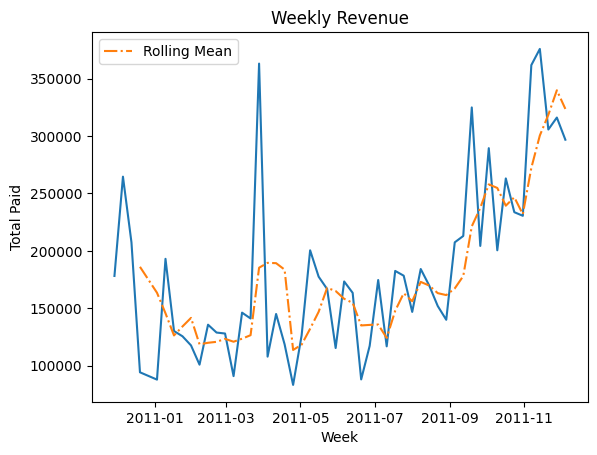

In [ ]:
plt.plot(revenue_weekly.index, revenue_weekly)
mean_per_week_revenue = revenue_weekly.rolling(4).mean()
plt.plot(revenue_weekly.index,mean_per_week_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid')
plt.title('Weekly Revenue')

Text(0.5, 1.0, 'Weekly Revenue')

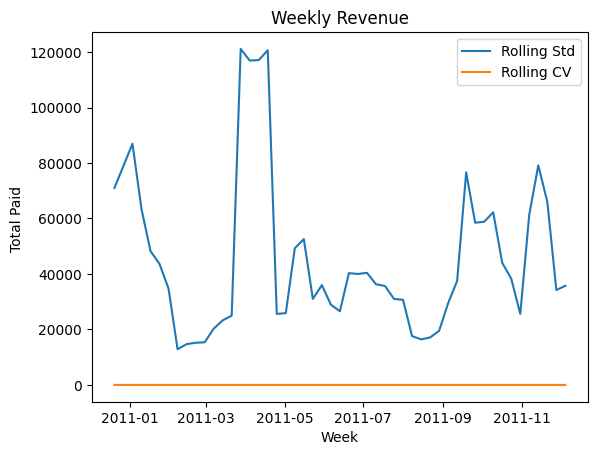

In [ ]:
std_per_week_revenue = revenue_weekly.rolling(4).std()
rolling_cv = std_per_week_revenue / mean_per_week_revenue
plt.plot(revenue_weekly.index,std_per_week_revenue,linestyle="-",label="Rolling Std")
plt.plot(revenue_weekly.index,rolling_cv,linestyle="-",label="Rolling CV")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid ')
plt.title('Weekly Revenue')

Text(0.5, 1.0, 'Weekly Revenue')

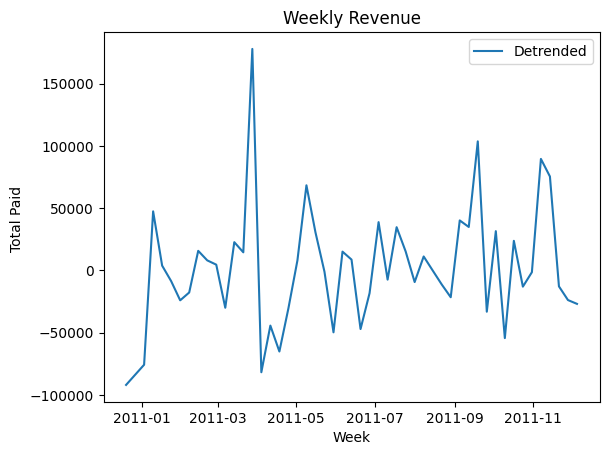

In [ ]:
detrended = revenue_weekly - mean_per_week_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid ')
plt.title('Weekly Revenue')

In [ ]:
print(revenue_weekly[revenue_weekly.isna()])
print(revenue_weekly.isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##After Log Transformation

The log transformation of the revenue is neccessary to stabilize the rolling mean and standard devation.

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

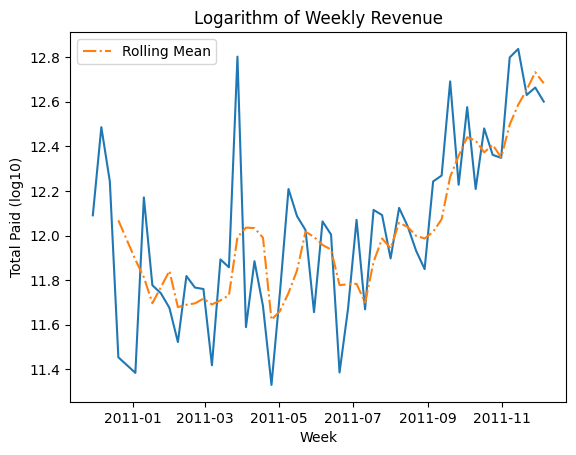

In [ ]:
plt.plot(revenue_weekly.index, np.log(revenue_weekly))
mean_per_week_revenue = np.log(revenue_weekly).rolling(4).mean()
plt.plot(revenue_weekly.index,mean_per_week_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

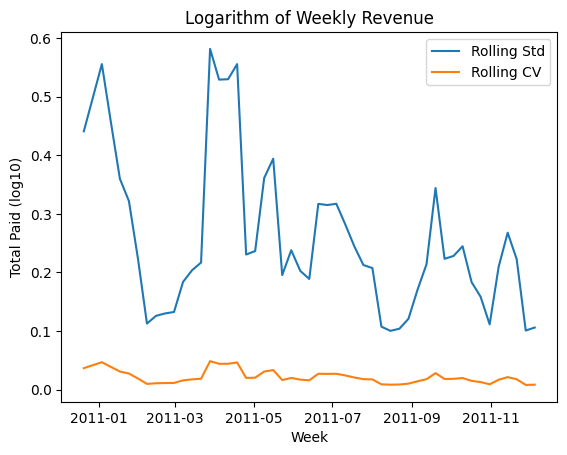

In [ ]:
std_per_week_revenue = np.log(revenue_weekly).rolling(4).std()
rolling_cv = std_per_week_revenue / mean_per_week_revenue
plt.plot(revenue_weekly.index,std_per_week_revenue,linestyle="-",label="Rolling Std")
plt.plot(revenue_weekly.index,rolling_cv,linestyle="-",label="Rolling CV")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

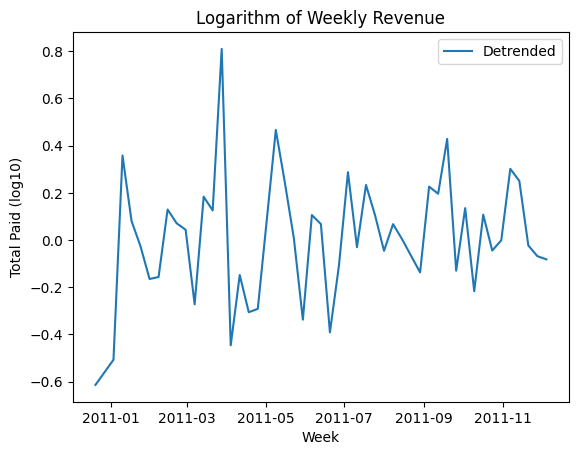

In [ ]:
detrended = np.log(revenue_weekly) - mean_per_week_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

In [ ]:
print(np.log(revenue_weekly)[np.log(revenue_weekly).isna()])
print(np.log(revenue_weekly).isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##After Differencing

Text(0.5, 1.0, 'Differenced Logarithm of Weekly Revenue')

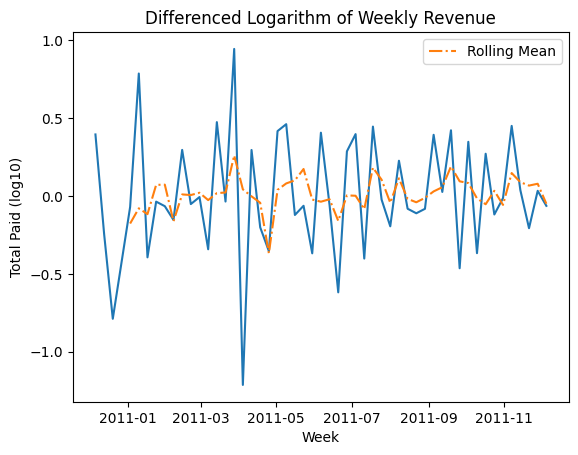

In [ ]:
log_revenue = np.log(revenue_weekly)
log_revenue_diff = log_revenue.diff()
log_revenue_diff = log_revenue_diff.dropna()
plt.plot(log_revenue_diff.index,log_revenue_diff)
mean_per_week_diff_revenue = log_revenue_diff.rolling(4).mean()
plt.plot(log_revenue_diff.index,mean_per_week_diff_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Differenced Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Differenced Logarithm of Weekly Revenue')

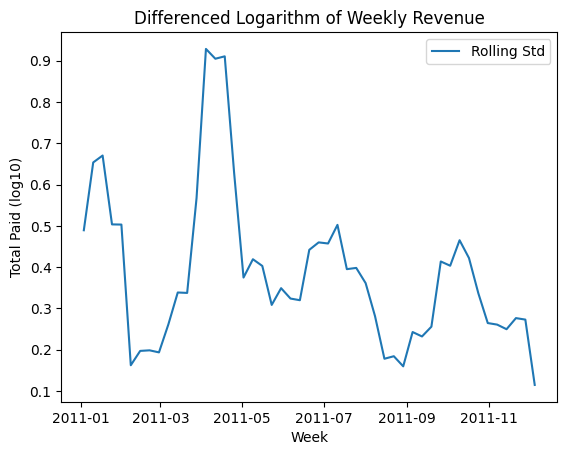

In [ ]:
std_per_week_diff_revenue = log_revenue_diff.rolling(4).std()

plt.plot(log_revenue_diff.index,std_per_week_diff_revenue,linestyle="-",label="Rolling Std")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Differenced Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

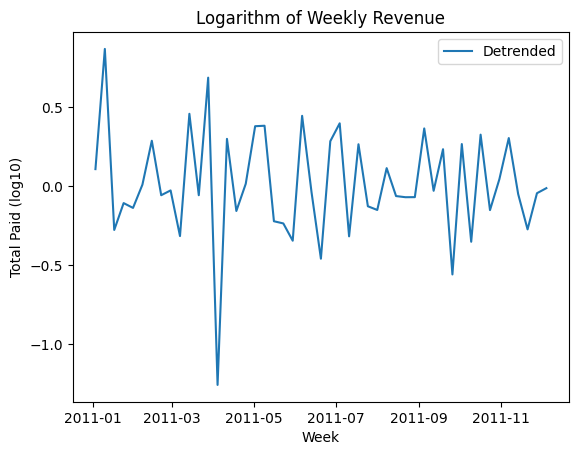

In [ ]:
detrended = log_revenue_diff - mean_per_week_diff_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

In [ ]:
print(log_revenue_diff[log_revenue_diff.isna()])
print(log_revenue_diff.isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##Rolling Statistics Choices

##Autocorrelation

In [ ]:
correlation_with_lagged_feature = []
for i in range(0,14):
  lagged_feature = log_revenue_diff.shift(i)
  correlation_with_lagged_feature.append({'Lag': i, 'Correlation':log_revenue_diff.corr(lagged_feature)})
print(type(correlation_with_lagged_feature))
print(type(correlation_with_lagged_feature[0]))
correlation_with_lagged_feature = pd.DataFrame(correlation_with_lagged_feature)
print(correlation_with_lagged_feature)


<class 'list'>
<class 'dict'>
    Lag  Correlation
0     0     1.000000
1     1    -0.416974
2     2    -0.048010
3     3    -0.061201
4     4     0.025565
5     5    -0.068029
6     6     0.149066
7     7    -0.152990
8     8     0.135422
9     9    -0.027324
10   10    -0.041346
11   11     0.310040
12   12    -0.374136
13   13    -0.078694


Text(0.5, 1.0, 'Autocorrelation of the transformed weekly revenue')

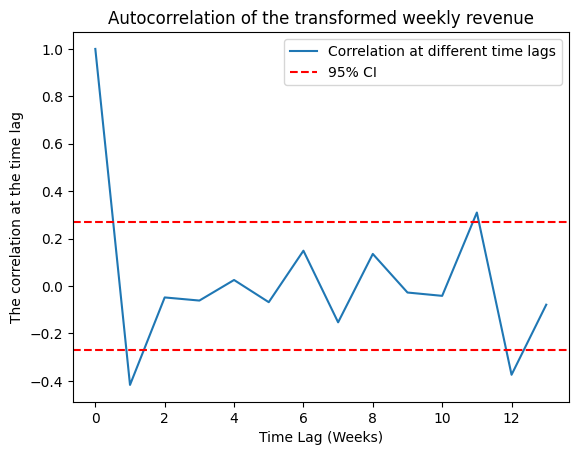

In [ ]:
plt.plot(correlation_with_lagged_feature['Lag'],correlation_with_lagged_feature['Correlation'],label='Correlation at different time lags')
conf_level = 1.96/np.sqrt(len(log_revenue_diff))
plt.axhline(conf_level, linestyle="--", color="red", label="95% CI")
plt.axhline(-conf_level, linestyle="--", color="red")
plt.legend()
plt.xlabel('Time Lag (Weeks)')
plt.ylabel('The correlation at the time lag')
plt.title('Autocorrelation of the transformed weekly revenue')

After transforming the time-series and computing autocorrelation for 13 lags, the majority of autocorrelation values appear to be fluctuating around 0 and fall within the 95% confidence interval, indicating that long term dependence has been removed. However, some short-term effects remain, with lag 2,11 and 12 exceeding the confidence interval, suggesting weak residual dependence.

##Partial Autocorrelation

In [ ]:
import statsmodels.api as sm

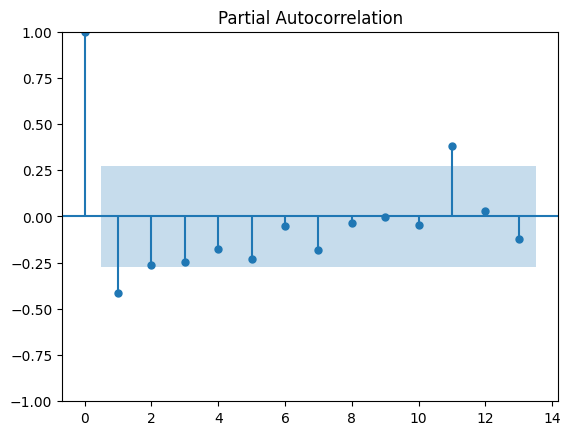

In [ ]:
# Calculate PACF
pacf_values = sm.tsa.pacf(log_revenue_diff, nlags=13)

# Plot PACF
sm.graphics.tsa.plot_pacf(log_revenue_diff, lags=13)
plt.show()

#ARIMA Model Choice

When looking at our autocorrelation plot it shows a significant lag at 1 which then seems to cut off with most remianing lags being within the confidence level which proposes a MA(1) model.

This is supported by our partial auto correlation plot which slowly decays after lag 1 showing no autoregression dependency.

Thus, ARIMA(0,1,1) seems like a suitable model to forecast the revenue of the online retailer. However, to find the most suitable model we also test the ARIMA(1,1,1) and ARIMA(1,1,0).

#Stationarity testing

##Augmented Dickey-Fuller Testing

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(log_revenue_diff)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.230866448890402
p-value: 0.19523401391421075
Critical Values:
	1%: -3.601
	5%: -2.935
	10%: -2.606


To confirm stationarity an augmented Dickey-Fuller test has been performed where our p-value of 0.195 > 0.05 confidence level. Consequently,failing to reject the null hypothesis indicating a presence of a unit root. However, as we seen the data already exhibits approximate stationarity and therefore it could be a type 2 error due to the small number of samples.

##Second Difference

Text(0.5, 1.0, '2nd Differenced Logarithm of Weekly Revenue')

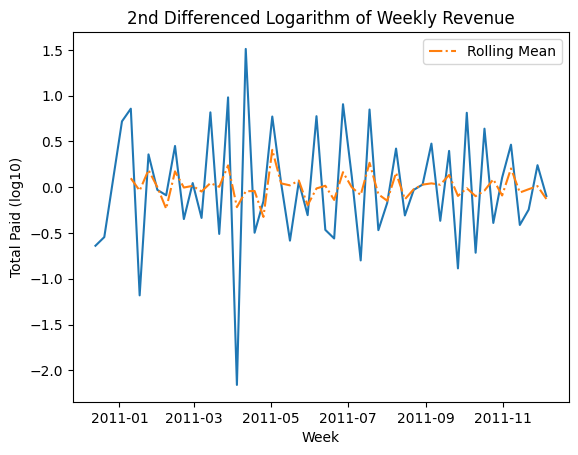

In [ ]:
log_revenue_diff_two = log_revenue_diff.diff()
log_revenue_diff_two = log_revenue_diff_two.dropna()
plt.plot(log_revenue_diff_two.index,log_revenue_diff_two)
mean_per_week_diff_two_revenue = log_revenue_diff_two.rolling(4).mean()
plt.plot(log_revenue_diff_two.index,mean_per_week_diff_two_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('2nd Differenced Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Differenced Logarithm of Weekly Revenue')

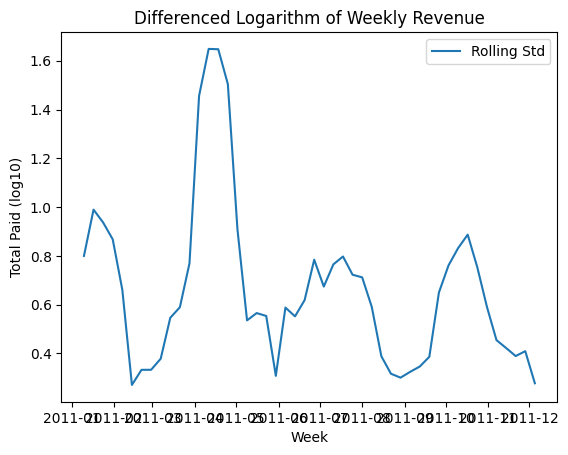

In [ ]:
std_per_week_diff_two_revenue = log_revenue_diff_two.rolling(4).std()

plt.plot(log_revenue_diff_two.index,std_per_week_diff_two_revenue,linestyle="-",label="Rolling Std")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Differenced Logarithm of Weekly Revenue')

###Repeat of Augmented Dickey-Fuller Test

After differencing the second time we repeat ADF and this time our ADF statistic is -6.67 which is more negative than the 3 significance levels below and thus there is enough evidence to reject the null hypothesis meaning that possibly our alternative hypothesis correct and the data does not contain any unit roots thus, it is non-stationary. However, as we can see from the graph of the 2nd difference the data shape is much closer to random noise which is a sign of over differencing and thus we will be only focusing on the first difference.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(log_revenue_diff_two)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.665758181448619
p-value: 4.7223866068860875e-09
Critical Values:
	1%: -3.601
	5%: -2.935
	10%: -2.606


#Train test split

To prepare the data into a train/test split a split of 80%/20% have been chosen and the data has been split chronologically, so the first 41 weeks of the year will be used as the training data and the other 11 weeks are used as the test data so the model mimicks a real forecasting scenario.

In [ ]:
train_size = int(len(log_revenue) * 0.80)
train, test = log_revenue[:train_size], log_revenue[train_size:]

# ARIMA fitting

In [ ]:
import statsmodels.api as sm
arima_baseline = sm.tsa.ARIMA(train,order=(0,1,1))
arima_test1 = sm.tsa.ARIMA(train,order=(1,1,1))
arima_test2 = sm.tsa.ARIMA(train,order=(1,1,0))

results_test1 = arima_test1.fit()
results_test2 = arima_test2.fit()
results_baseline = arima_baseline.fit()

print(results_baseline.summary())
print(results_test1.summary())
print(results_test2.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              TotalPaid   No. Observations:                   42
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -14.189
Date:                Sun, 29 Mar 2026   AIC                             32.378
Time:                        23:59:53   BIC                             35.805
Sample:                             0   HQIC                            33.626
                                 - 42                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8522      0.141     -6.045      0.000      -1.129      -0.576
sigma2         0.1133      0.021      5.357      0.000       0.072       0.155
Ljung-Box (L1) (Q):                   0.66   Jarque-

The 3 candidate models defined above have been fit to the full training data. When we compare the AIC and BIC of each model we can see that ARIMA(0,1,1) has the lowest AIC and BIC making it the most suitable model for forecasting the data. When looking at the significance of coefficients at  a 95% significance level we can see that the probability of the ARIMA(0,1,1) coefficient p < 0.05, indicating that past shocks have a meaningful effect on the current change in the series. This is also suggested by the ARIMA(1,1,1) model as the AR coefficients probability p > 0.05 where as the MA coefficients probability p < 0.05.

##Static ARIMA

###Residual Diagnostic

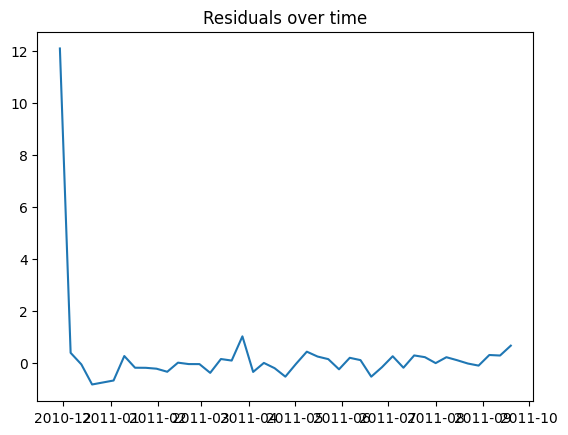

In [ ]:
residuals =  results_baseline.resid
plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

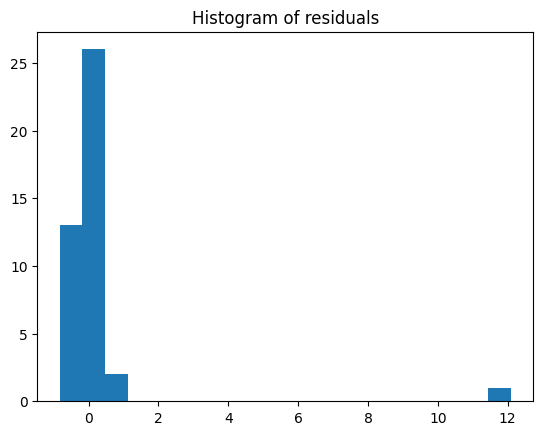

In [ ]:
plt.hist(residuals,bins=20)
plt.title("Histogram of residuals")
plt.show()

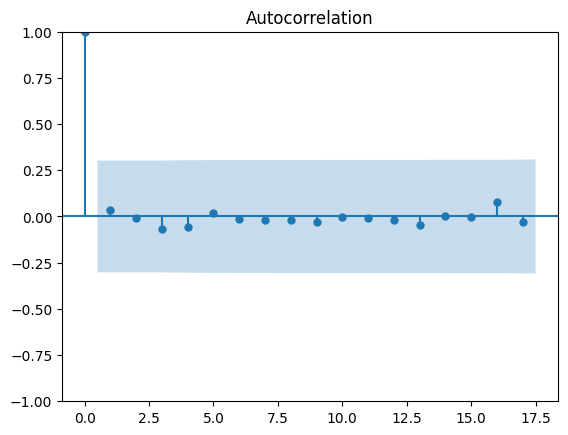

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()

The residuals over time from the ARIMA model represent the unexplained components of the series by the model which should behave like white noise. Diagnostic plots such as residual time series, histogram, and autocorrelation function are used to assess whether the residuals are independent and identically distributed. The absence of patterns, the constant distribution of residuals over time and absence of significant spikes in the autocorrelation indicates a well fitted model. However, there is a large residual at the beginning this is likely due to initialization effects which does not persist. When lookin at the Ljung-box test we can see that the probability p > 0.05 and thus the alternative hypothesis is rejected, indicating no significant autocorrelation.

###Forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


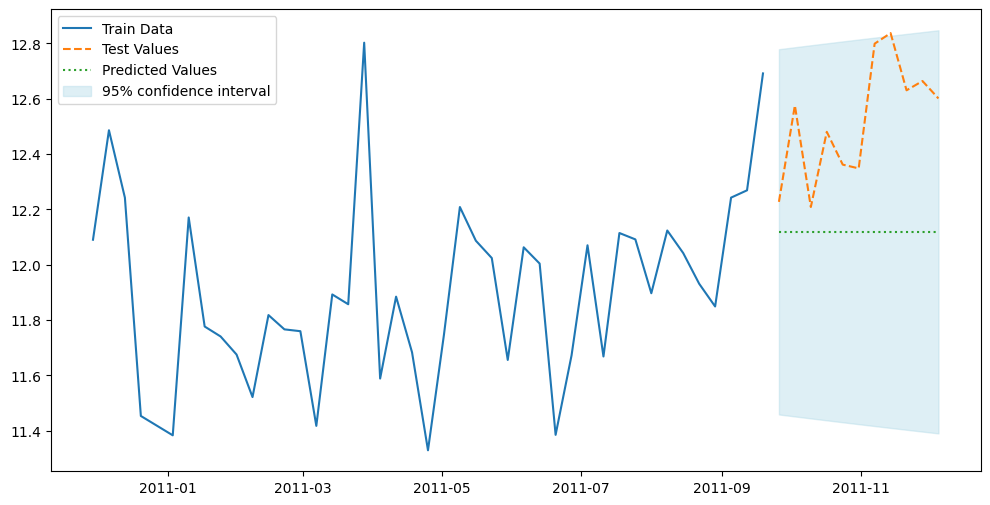

In [ ]:
forecast = results_baseline.get_forecast(len(test))
mean_forecast = forecast.predicted_mean
conf_level = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, mean_forecast,label='Predicted Values',linestyle=':')
plt.fill_between(test.index, conf_level.iloc[:, 0], conf_level.iloc[:, 1], color='lightblue', alpha=0.4,label="95% confidence interval")
plt.legend()

The forecast shows a straight line due to using a static ARIMA forecast. This is because the future error terms of the ARIMA model are assumed to have zero expectation, as the forecast tries to predict further into the future the influence of past shocks disappears. Consequently, the model predicts no further changes in a differenced series, collapsing to a constant, resulting in a flat forecast line.

##Walk-forward ARIMA

In [ ]:
history = list(train)
predictions = []
lower_ci = []
upper_ci = []
model_fit = None
for t in range(len(test)):
    model = sm.tsa.ARIMA(history, order=(0, 1, 1))
    model_fit = model.fit()

    forecast = model_fit.get_forecast(steps=1)
    mean_forecast = forecast.predicted_mean[0]
    conf_interval = forecast.conf_int()

    predictions.append(mean_forecast)
    lower_ci.append(conf_interval[0, 0])
    upper_ci.append(conf_interval[0, 1])


    history.append(test[t])

/tmp/ipykernel_19403/2233862333.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  history.append(test[t])


In [ ]:
pred_series = pd.Series(predictions, index=test.index)
lower_ci_series = pd.Series(lower_ci, index=test.index)
upper_ci_series = pd.Series(upper_ci, index=test.index)

###Residual Diagnostic

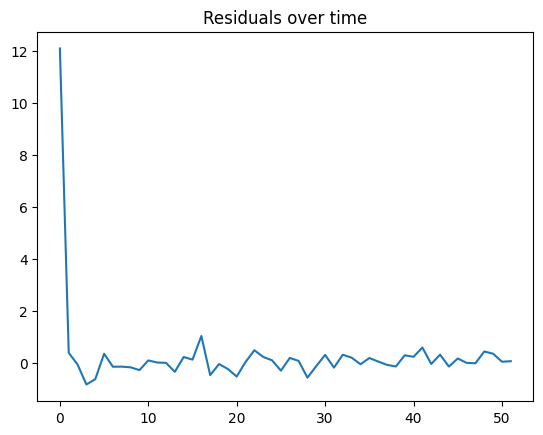

In [ ]:
residuals = pd.DataFrame(model_fit.resid)

plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

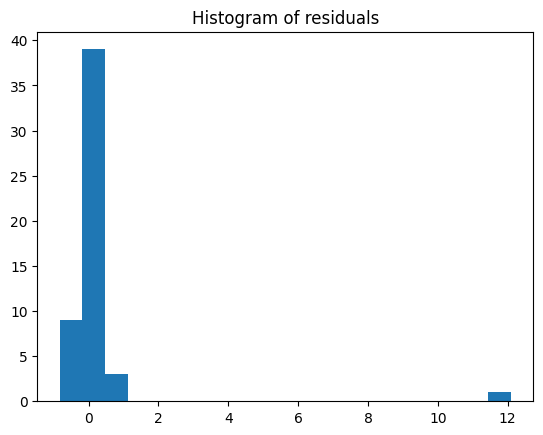

In [ ]:
plt.hist(residuals,bins=20)
plt.title("Histogram of residuals")
plt.show()

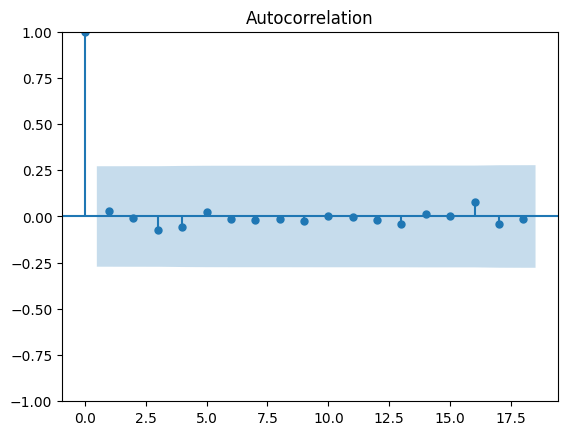

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
errors_df = pd.DataFrame(residuals)
plot_acf(errors_df)
plt.show()

In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   52
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -14.918
Date:                Mon, 30 Mar 2026   AIC                             33.836
Time:                        00:14:34   BIC                             37.699
Sample:                             0   HQIC                            35.312
                                 - 52                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7206      0.119     -6.046      0.000      -0.954      -0.487
sigma2         0.1036      0.016      6.341      0.000       0.072       0.136
Ljung-Box (L1) (Q):                   0.14   Jarque-

When performing residual diagnostic on the walk-forward ARIMA, the residuals once again exhibit a white noise pattern with no autocorrelation which is supported by both the autocorrelation plot and due to the Ljung-Box probability p > 0.14, consequently rejecting the alternative hypothesis suggesting there is no significant autocorrelation. Which indicates that the model is a good fit.

###Forecast

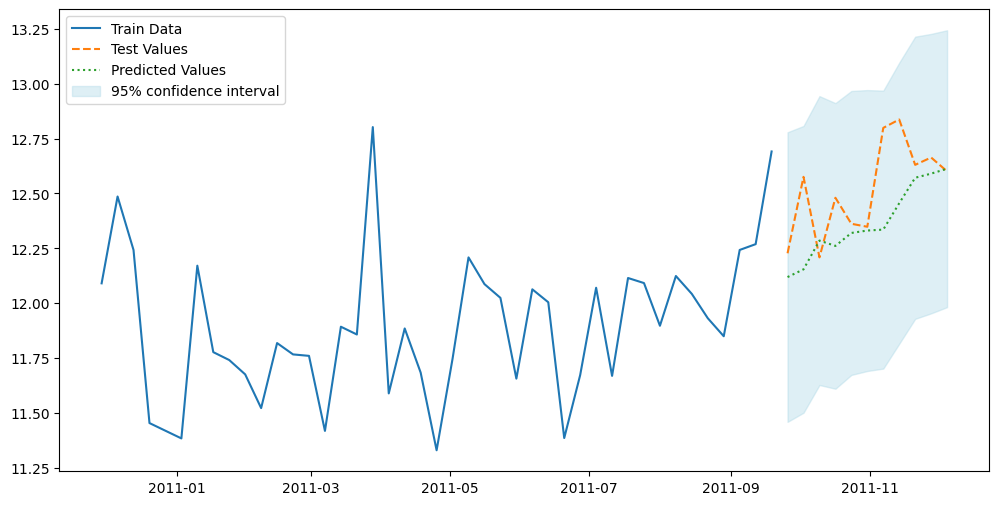

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, pred_series,label='Predicted Values',linestyle=':')
plt.fill_between(test.index, lower_ci_series, upper_ci_series,color='lightblue', alpha=0.4,label="95% confidence interval")
plt.legend()

Use of the walk forward approach which iteratively updates the ARIMA model after each new observation has improved the forecast quality. This approach allows the model to incorporate newly observed values and shocks, leading to more adaptive and realistic forecasts compared to a static ARIMA forecast.



##Naive Baseline

To be able to judge the accuracy of the ARIMA model a naive model has been calculated which uses the lagged version of the test set as the prediction such that y(t) = y(t-1).

In [ ]:
naive_pred = test.shift(1)
naive_pred.iloc[0] = train.iloc[-1]

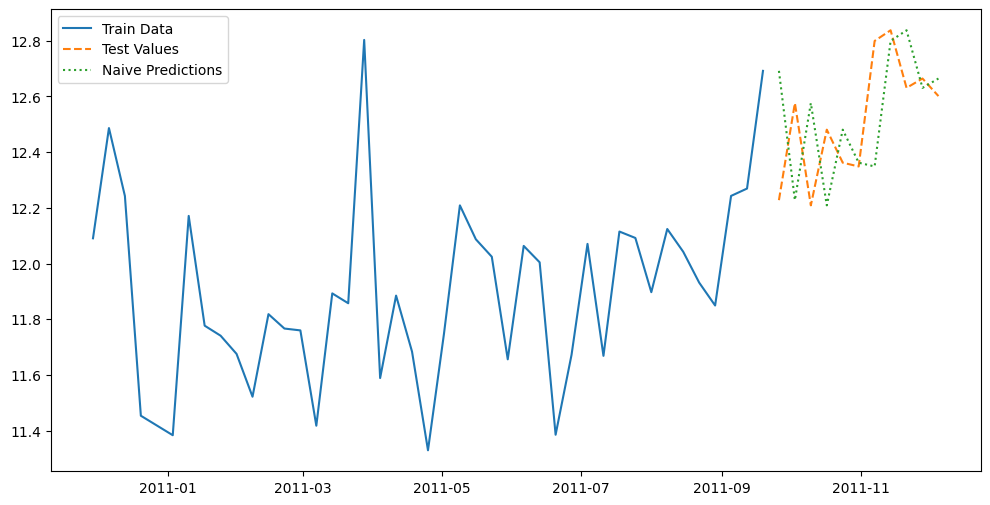

In [ ]:


plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, naive_pred,label='Naive Predictions',linestyle=':')
plt.legend()

#Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test, mean_forecast)
print("The mean absolute error between the actual revenue and the predicted values:",mae)

The mean absolute error between the actual revenue and the predicted values: 0.40223676273605347


In [ ]:
rw_mae = mean_absolute_error(test, pred_series)
print("The mean absolute error between the actual revenue and the predicted values using the walk-forward approach:",rw_mae)

The mean absolute error between the actual revenue and the predicted values using the walk-forward approach: 0.170410636981937


In [ ]:
from sklearn.metrics import mean_absolute_error
naive_mae = mean_absolute_error(test, naive_pred)

print("The mean absolute error between the actual revenue and the predicted values using the naive approach:",naive_mae)

The mean absolute error between the actual revenue and the predicted values using the naive approach: 0.2159380720279613


Model | MAE
-------------------|---------------
Walk-Forward ARIMA | 0.170
Naive              | 0.216
Static ARIMA       | 0.402   


#Conclusion

An ARIMA(0,1,1) has been chosen based on the lowest information criteria, which was able to capture short-term dependencies in the weekly logarithm of the revenue. When evaluated against a naive baseline, the walk-forward ARIMA model achieved a lower forecast error, indicating that it provides additional predictive value.

The comparison between static and walk-forward forecasting shows the importance of model updating, with walk forward validation providing a more realistic assessment of predictive performance.

Although the improvement over the naive baseline is modest, this suggest that while the series contains some predictable structure, it still retains characteristics of a near-random-walk process.

A limitiation of the analysis is the relatively small dataset and the absence of seasonal or external variables. Future work will explore SARIMA and machine learning approaches to determine whether additional structure can be captured with the ARIMA(0,1,1) as a baseline.